# 01 — Seleksi Fitur Berbasis SHAP

**Tujuan:** Menguji apakah menyeleksi subset fitur (top-k berdasar ranking
`mean |SHAP value|`) lalu **melatih ulang** model bisa menyamai atau
mengalahkan baseline 182 fitur — dengan model lebih ringkas & interpretasi
lebih bersih.

**Konteks:** pipeline resmi (`notebooks/`) memakai SEMUA 182 fitur (164
kanonik + 18 DDS); SHAP di `notebooks/04` & `06` cuma untuk *interpretasi*,
tidak pernah dipakai memangkas fitur. Notebook ini menutup celah itu.

**Aturan main** (sama seperti `experiments/` lain): val set untuk iterasi &
memilih k, test set disentuh **sekali** di akhir untuk kandidat terpilih.
Tidak mengubah `data/processed/` atau `outputs/models/` resmi.

**Prioritas metrik:** F1 macro (class imbalance ekstrem), lalu accuracy.
Ranking berbasis metrik global condong ke kelas mayoritas → Bagian 5
memeriksa dampak per-kelas untuk kontrak langka.

## 0. Setup

In [1]:
import sys, json, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import shap

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

from src.preprocessing import load_splits
from src.models import RFModel, XGBModel, LGBMModel
from src.evaluation import evaluate, print_summary, compare_models

OUT = ROOT / "experiments" / "2026-08-31" / "outputs" / "shap_feature_selection"
OUT.mkdir(parents=True, exist_ok=True)

CONFIG = yaml.safe_load((ROOT / "configs" / "config.yaml").read_text())
XGB_CFG  = CONFIG["models"]["xgboost"]
LGBM_CFG = CONFIG["models"]["lightgbm"]

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
print("shap", shap.__version__, "| setup selesai")

shap 0.52.0 | setup selesai


## 1. Load Dataset (182 fitur resmi)

In [2]:
df_train, df_val, df_test, feature_cols, le = load_splits(ROOT / "data" / "processed")

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train["label"].values
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val["label"].values
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test["label"].values

feature_cols = list(feature_cols)
n_features = len(feature_cols)
class_names = list(le.classes_)
print(f"Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}")
print(f"{n_features} fitur, {len(class_names)} kelas")


def feat_group(name):
    if name.startswith(("ns_dd", "ew_dd", "dd_par")): return "DDS"
    if name.startswith(("ns_", "ew_", "hcp_ns")):     return "Partnership"
    if len(name) >= 2 and name[0] in "NESW" and name[1] == "_": return "Per-seat"
    if name.startswith(("dealer_", "vuln_")):         return "Deal"
    if name.startswith(("auction_", "opening_")):     return "Auction"
    return "Lain"

Train (34832, 182) | Val (7462, 182) | Test (7461, 182)
182 fitur, 36 kelas


## 2. Baseline — 182 fitur

Latih ulang LightGBM (`class_weight="balanced"`) + XGBoost (default
`config.yaml`) di seluruh 182 fitur, evaluasi di **val set**. Titik
pembanding untuk seluruh eksperimen di bawah.

In [3]:
def fit_eval(model_kind, cols, Xtr, Xev, yev, name):
    idx = [feature_cols.index(c) for c in cols]
    if model_kind == "lgbm":
        m = LGBMModel(**LGBM_CFG)
    else:
        m = XGBModel(**XGB_CFG)
    t0 = time.time()
    m.fit(Xtr[:, idx], y_train)
    dt = time.time() - t0
    res = evaluate(yev, m.predict(Xev[:, idx]), m.predict_proba(Xev[:, idx]), le, model_name=name)
    res["fit_seconds"] = round(dt, 1)
    res["n_features"] = len(cols)
    return m, res

base_lgbm_m, base_lgbm = fit_eval("lgbm", feature_cols, X_train, X_val, y_val, "LightGBM 182 (baseline)")
base_xgb_m,  base_xgb  = fit_eval("xgb",  feature_cols, X_train, X_val, y_val, "XGBoost 182 (baseline)")
print_summary(base_lgbm); print(f"  fit {base_lgbm['fit_seconds']}s\n")
print_summary(base_xgb);  print(f"  fit {base_xgb['fit_seconds']}s")


  LightGBM 182 (baseline)
  Accuracy          : 0.5528
  Precision (macro) : 0.4380
  Recall (macro)    : 0.3709
  F1 (macro)        : 0.3888
  F1 (weighted)     : 0.5434
  Top-3 Accuracy    : 0.8171
  Top-5 Accuracy    : 0.8943
  fit 85.4s


  XGBoost 182 (baseline)
  Accuracy          : 0.5657
  Precision (macro) : 0.4696
  Recall (macro)    : 0.3542
  F1 (macro)        : 0.3872
  F1 (weighted)     : 0.5431
  Top-3 Accuracy    : 0.8204
  Top-5 Accuracy    : 0.9026
  fit 123.4s


## 3. Ranking Fitur via SHAP

`shap.TreeExplainer` pada sub-sampel **train** (2.000 baris). Untuk model
multikelas, `shap_values` berbentuk `(n_sampel, 182, 36)` — importance
global tiap fitur = rata-rata `|SHAP|` **atas sampel dan kelas**.

In [4]:
SAMPLE_N = 2000
rng = np.random.default_rng(42)
samp = rng.choice(len(X_train), size=min(SAMPLE_N, len(X_train)), replace=False)
X_samp = X_train[samp]

def shap_importance(clf, X):
    sv = shap.TreeExplainer(clf).shap_values(X)
    arr = np.array(sv)
    if arr.ndim == 2:                 # (n, features)
        imp = np.abs(arr).mean(axis=0)
    elif arr.shape[0] == X.shape[0]:  # (n, features, classes)
        imp = np.abs(arr).mean(axis=(0, 2))
    else:                            # (classes, n, features)
        imp = np.abs(arr).mean(axis=(0, 1))
    return imp

t0 = time.time()
imp_lgbm = shap_importance(base_lgbm_m.clf, X_samp)
imp_xgb  = shap_importance(base_xgb_m.clf,  X_samp)
print(f"SHAP dihitung dalam {time.time()-t0:.0f}s")

rank_df = pd.DataFrame({
    "feature": feature_cols,
    "group": [feat_group(c) for c in feature_cols],
    "shap_lgbm": imp_lgbm,
    "shap_xgb": imp_xgb,
})
rank_df["rank_lgbm"] = rank_df["shap_lgbm"].rank(ascending=False).astype(int)
rank_df["rank_xgb"]  = rank_df["shap_xgb"].rank(ascending=False).astype(int)
rank_df = rank_df.sort_values("shap_lgbm", ascending=False).reset_index(drop=True)
rank_df.to_csv(OUT / "shap_feature_ranking.csv", index=False)

print("\n=== Top 20 fitur (SHAP LightGBM) ===")
print(rank_df.head(20)[["feature", "group", "shap_lgbm", "rank_xgb"]].to_string(index=False))
print("\n=== 15 fitur terbawah (SHAP LightGBM) ===")
print(rank_df.tail(15)[["feature", "group", "shap_lgbm", "rank_xgb"]].to_string(index=False))

SHAP dihitung dalam 312s

=== Top 20 fitur (SHAP LightGBM) ===
            feature       group  shap_lgbm  rank_xgb
    auction_ew_bids     Auction   0.392324         3
        auction_len     Auction   0.383034         1
    auction_ns_bids     Auction   0.379686         4
       dd_par_level         DDS   0.327666         2
      opening_level     Auction   0.209848         6
auction_competitive     Auction   0.175085         7
             ns_hcp Partnership   0.154584         5
        ns_best_fit Partnership   0.137283         8
        ew_best_fit Partnership   0.099666        13
             ns_ltc Partnership   0.097221        10
           ns_fit_S Partnership   0.094310        11
   opening_strain_C     Auction   0.091807         9
             ew_ltc Partnership   0.087811        14
           ns_fit_H Partnership   0.079863        12
   opening_strain_N     Auction   0.070735        30
            ew_dd_H         DDS   0.061887        15
             ew_hcp Partnership   0.

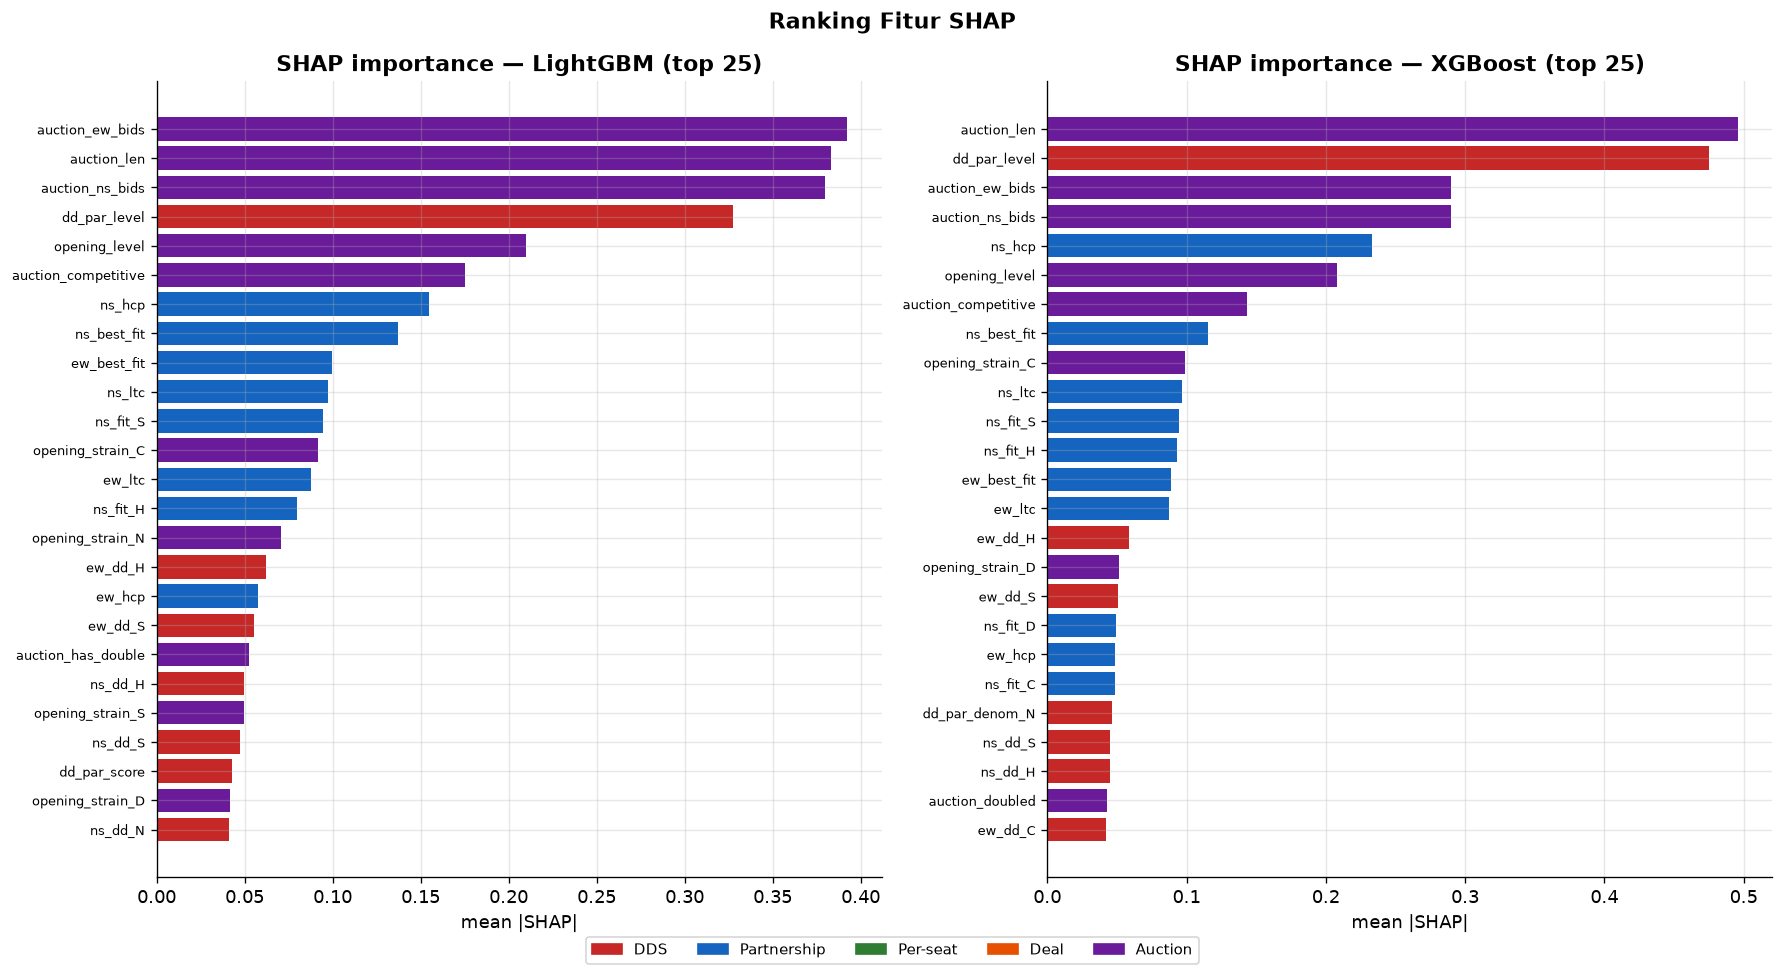

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, col, title in [(axes[0], "shap_lgbm", "LightGBM"), (axes[1], "shap_xgb", "XGBoost")]:
    top = rank_df.sort_values(col, ascending=False).head(25).iloc[::-1]
    gcol = {"DDS": "#C62828", "Partnership": "#1565C0", "Per-seat": "#2E7D32",
            "Deal": "#E65100", "Auction": "#6A1B9A", "Lain": "#777"}
    ax.barh(range(len(top)), top[col], color=[gcol[g] for g in top["group"]])
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top["feature"], fontsize=8)
    ax.set_title(f"SHAP importance — {title} (top 25)", fontweight="bold")
    ax.set_xlabel("mean |SHAP|")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=c, label=g) for g, c in
                    {"DDS": "#C62828", "Partnership": "#1565C0", "Per-seat": "#2E7D32",
                     "Deal": "#E65100", "Auction": "#6A1B9A"}.items()],
           loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Ranking Fitur SHAP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "shap_ranking.png", bbox_inches="tight")
plt.show()

## 4. Retrain di Top-k Fitur

Untuk tiap `k`, ambil `k` fitur teratas menurut ranking SHAP **model itu
sendiri** (LightGBM pakai `rank_lgbm`, XGBoost pakai `rank_xgb`), latih
ulang, evaluasi di val set.

In [6]:
K_GRID = [15, 25, 40, 60, 90, 120, 150, 182]
sweep = []

order_lgbm = rank_df.sort_values("shap_lgbm", ascending=False)["feature"].tolist()
order_xgb  = rank_df.sort_values("shap_xgb",  ascending=False)["feature"].tolist()

for k in K_GRID:
    for kind, order, base in [("lgbm", order_lgbm, base_lgbm), ("xgb", order_xgb, base_xgb)]:
        cols_k = order[:k]
        _, r = fit_eval(kind, cols_k, X_train, X_val, y_val, f"{kind}-top{k}")
        sweep.append({"model": kind.upper(), "k": k,
                      "accuracy": r["accuracy"], "f1_macro": r["f1_macro"],
                      "f1_weighted": r["f1_weighted"],
                      "top_3": r.get("top_3_accuracy", 0), "top_5": r.get("top_5_accuracy", 0),
                      "fit_s": r["fit_seconds"]})
        print(f"[{kind:4} k={k:3}] acc={r['accuracy']:.4f} f1m={r['f1_macro']:.4f} "
              f"f1w={r['f1_weighted']:.4f} ({r['fit_seconds']}s)")

sweep_df = pd.DataFrame(sweep)
sweep_df.to_csv(OUT / "sweep_val.csv", index=False)

[lgbm k= 15] acc=0.4989 f1m=0.3275 f1w=0.5073 (33.7s)


[xgb  k= 15] acc=0.5336 f1m=0.3281 f1w=0.5061 (39.1s)


[lgbm k= 25] acc=0.5281 f1m=0.3729 f1w=0.5294 (40.0s)


[xgb  k= 25] acc=0.5583 f1m=0.3886 f1w=0.5372 (41.5s)


[lgbm k= 40] acc=0.5507 f1m=0.3975 f1w=0.5477 (50.1s)


...

[xgb  k=120] acc=0.5647 f1m=0.3815 f1w=0.5428 (89.1s)


[lgbm k=150] acc=0.5528 f1m=0.3961 f1w=0.5440 (110.4s)


[xgb  k=150] acc=0.5634 f1m=0.3817 f1w=0.5408 (98.0s)


[lgbm k=182] acc=0.5555 f1m=0.3969 f1w=0.5464 (95.4s)


[xgb  k=182] acc=0.5614 f1m=0.3759 f1w=0.5391 (136.4s)


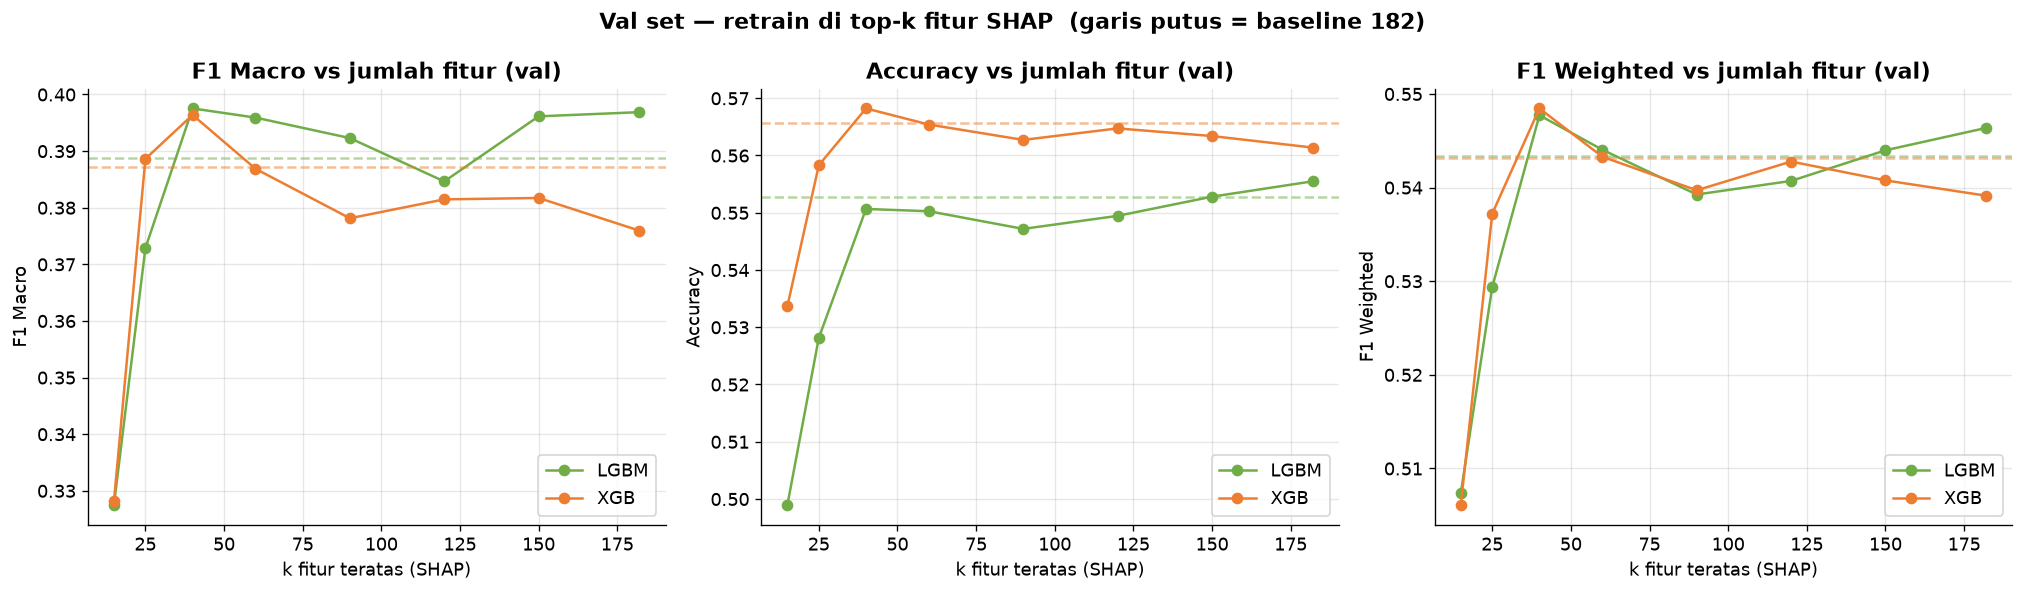

=== Ringkasan val (selisih vs baseline 182) ===

LGBM  (baseline: acc=0.5528  f1m=0.3888)
  k= 15: acc 0.4989 (-5.39pp)   f1m 0.3275 (-6.13pp)
  k= 25: acc 0.5281 (-2.47pp)   f1m 0.3729 (-1.59pp)
  k= 40: acc 0.5507 (-0.21pp)   f1m 0.3975 (+0.87pp)
  k= 60: acc 0.5503 (-0.25pp)   f1m 0.3959 (+0.71pp)
  k= 90: acc 0.5472 (-0.56pp)   f1m 0.3923 (+0.35pp)
  k=120: acc 0.5495 (-0.34pp)   f1m 0.3846 (-0.42pp)
  k=150: acc 0.5528 (+0.00pp)   f1m 0.3961 (+0.73pp)
  k=182: acc 0.5555 (+0.27pp)   f1m 0.3969 (+0.81pp)

XGB  (baseline: acc=0.5657  f1m=0.3872)
  k= 15: acc 0.5336 (-3.20pp)   f1m 0.3281 (-5.90pp)
  k= 25: acc 0.5583 (-0.74pp)   f1m 0.3886 (+0.15pp)
  k= 40: acc 0.5682 (+0.25pp)   f1m 0.3964 (+0.92pp)
  k= 60: acc 0.5654 (-0.03pp)   f1m 0.3869 (-0.03pp)
  k= 90: acc 0.5627 (-0.29pp)   f1m 0.3781 (-0.90pp)
  k=120: acc 0.5647 (-0.09pp)   f1m 0.3815 (-0.57pp)
  k=150: acc 0.5634 (-0.23pp)   f1m 0.3817 (-0.54pp)
  k=182: acc 0.5614 (-0.43pp)   f1m 0.3759 (-1.12pp)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, metric, label in [(axes[0], "f1_macro", "F1 Macro"),
                          (axes[1], "accuracy", "Accuracy"),
                          (axes[2], "f1_weighted", "F1 Weighted")]:
    for kind, color in [("LGBM", "#70AD47"), ("XGB", "#ED7D31")]:
        d = sweep_df[sweep_df.model == kind]
        ax.plot(d.k, d[metric], "o-", color=color, label=kind)
        base_v = (base_lgbm if kind == "LGBM" else base_xgb)[metric]
        ax.axhline(base_v, color=color, ls="--", alpha=0.5)
    ax.set_title(f"{label} vs jumlah fitur (val)", fontweight="bold")
    ax.set_xlabel("k fitur teratas (SHAP)"); ax.set_ylabel(label)
    ax.legend()
plt.suptitle("Val set — retrain di top-k fitur SHAP  (garis putus = baseline 182)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "sweep_val.png", bbox_inches="tight")
plt.show()

print("=== Ringkasan val (selisih vs baseline 182) ===")
for kind, base in [("LGBM", base_lgbm), ("XGB", base_xgb)]:
    print(f"\n{kind}  (baseline: acc={base['accuracy']:.4f}  f1m={base['f1_macro']:.4f})")
    for _, row in sweep_df[sweep_df.model == kind].iterrows():
        print(f"  k={int(row.k):3}: acc {row.accuracy:.4f} ({(row.accuracy-base['accuracy'])*100:+.2f}pp)"
              f"   f1m {row.f1_macro:.4f} ({(row.f1_macro-base['f1_macro'])*100:+.2f}pp)")

## 5. Analisis Per-Kelas — Kontrak Langka

Ranking SHAP mengagregasi seluruh kelas, jadi bisa menjatuhkan fitur yang
penting HANYA untuk kontrak jarang (slam). Bandingkan F1 per-kelas
`k` sedang vs 182 fitur, untuk model dengan F1 macro val terbaik.

In [8]:
from sklearn.metrics import f1_score

best_val = sweep_df.loc[sweep_df["f1_macro"].idxmax()]
best_kind = "lgbm" if best_val.model == "LGBM" else "xgb"
best_k = int(best_val.k)
order = order_lgbm if best_kind == "lgbm" else order_xgb
print(f"F1 macro val terbaik: {best_val.model} k={best_k} (f1m={best_val.f1_macro:.4f})")

m_k, _ = fit_eval(best_kind, order[:best_k], X_train, X_val, y_val, "best_k")
base_m = base_lgbm_m if best_kind == "lgbm" else base_xgb_m

idx_k = [feature_cols.index(c) for c in order[:best_k]]
f1_k    = f1_score(y_val, m_k.predict(X_val[:, idx_k]), labels=range(len(class_names)), average=None, zero_division=0)
f1_full = f1_score(y_val, base_m.predict(X_val), labels=range(len(class_names)), average=None, zero_division=0)

val_cnt = Counter(y_val)
rows = []
for i, name in enumerate(class_names):
    rows.append({"kontrak": name, "n_val": val_cnt.get(i, 0),
                 "f1_182": f1_full[i], f"f1_top{best_k}": f1_k[i],
                 "delta": f1_k[i] - f1_full[i]})
pc = pd.DataFrame(rows).sort_values("n_val")
pc.to_csv(OUT / "per_class_val.csv", index=False)

print("\n=== 12 kontrak paling langka (val) ===")
print(pc.head(12).to_string(index=False))
print(f"\nF1 macro  182 : {f1_full.mean():.4f}")
print(f"F1 macro  top{best_k}: {f1_k.mean():.4f}")
print(f"Kelas dengan F1 turun >0.02: {(pc['delta'] < -0.02).sum()} / {len(pc)}")

F1 macro val terbaik: LGBM k=40 (f1m=0.3975)



=== 12 kontrak paling langka (val) ===
kontrak  n_val   f1_182  f1_top40     delta
     5N      3 0.000000  0.000000  0.000000
     1C      6 0.833333  0.923077  0.089744
     7C      9 0.285714  0.266667 -0.019048
     7D     10 0.153846  0.133333 -0.020513
     7N     10 0.266667  0.266667  0.000000
     1D     12 0.869565  0.916667  0.047101
     7S     14 0.454545  0.400000 -0.054545
     7H     18 0.370370  0.375000  0.004630
     1H     24 0.193548  0.242424  0.048876
     4N     31 0.045455  0.085106  0.039652
   PASS     45 0.588235  0.603774  0.015538
     1S     48 0.424242  0.351351 -0.072891

F1 macro  182 : 0.3888
F1 macro  top40: 0.3975
Kelas dengan F1 turun >0.02: 8 / 36


## 6. Evaluasi Test Set — Kandidat Terpilih (sekali)

In [9]:
# Kandidat: (a) F1-macro val terbaik, (b) k terkecil yang F1 macro-nya masih
# dalam 0.5pp dari baseline (model paling ringkas yang "tak kalah")
candidates = {}
candidates[f"{best_val.model} top-{best_k} (F1m val terbaik)"] = (best_kind, best_k)

for kind, base in [("lgbm", base_lgbm), ("xgb", base_xgb)]:
    d = sweep_df[(sweep_df.model == kind.upper())].sort_values("k")
    ok = d[d.f1_macro >= base["f1_macro"] - 0.005]
    if len(ok):
        kk = int(ok.iloc[0].k)
        candidates[f"{kind.upper()} top-{kk} (paling ringkas, tak kalah)"] = (kind, kk)

test_rows = []
# baseline 182 di test
for kind, mm, nm in [("lgbm", base_lgbm_m, "LightGBM 182 (baseline)"),
                     ("xgb", base_xgb_m, "XGBoost 182 (baseline)")]:
    r = evaluate(y_test, mm.predict(X_test), mm.predict_proba(X_test), le, model_name=nm)
    test_rows.append({"kandidat": nm, "k": 182,
                      "accuracy": r["accuracy"], "f1_macro": r["f1_macro"],
                      "f1_weighted": r["f1_weighted"],
                      "top_3": r["top_3_accuracy"], "top_5": r["top_5_accuracy"]})

for label, (kind, k) in candidates.items():
    order = order_lgbm if kind == "lgbm" else order_xgb
    cols_k = order[:k]
    idx_k = [feature_cols.index(c) for c in cols_k]
    m = LGBMModel(**LGBM_CFG) if kind == "lgbm" else XGBModel(**XGB_CFG)
    m.fit(X_train[:, idx_k], y_train)
    r = evaluate(y_test, m.predict(X_test[:, idx_k]), m.predict_proba(X_test[:, idx_k]),
                 le, model_name=label)
    test_rows.append({"kandidat": label, "k": k,
                      "accuracy": r["accuracy"], "f1_macro": r["f1_macro"],
                      "f1_weighted": r["f1_weighted"],
                      "top_3": r["top_3_accuracy"], "top_5": r["top_5_accuracy"]})
    print_summary(r)

test_df = pd.DataFrame(test_rows)
test_df.to_csv(OUT / "test_comparison.csv", index=False)
print("\n" + test_df.to_string(index=False))


  LGBM top-40 (F1m val terbaik)
  Accuracy          : 0.5609
  Precision (macro) : 0.4386
  Recall (macro)    : 0.4063
  F1 (macro)        : 0.4142
  F1 (weighted)     : 0.5598
  Top-3 Accuracy    : 0.8227
  Top-5 Accuracy    : 0.9004



  LGBM top-40 (paling ringkas, tak kalah)
  Accuracy          : 0.5609
  Precision (macro) : 0.4386
  Recall (macro)    : 0.4063
  F1 (macro)        : 0.4142
  F1 (weighted)     : 0.5598
  Top-3 Accuracy    : 0.8227
  Top-5 Accuracy    : 0.9004



  XGB top-25 (paling ringkas, tak kalah)
  Accuracy          : 0.5765
  Precision (macro) : 0.4435
  Recall (macro)    : 0.3775
  F1 (macro)        : 0.3917
  F1 (weighted)     : 0.5571
  Top-3 Accuracy    : 0.8227
  Top-5 Accuracy    : 0.9081

                               kandidat   k  accuracy  f1_macro  f1_weighted    top_3    top_5
                LightGBM 182 (baseline) 182  0.563865  0.410098     0.556675 0.820802 0.897199
                 XGBoost 182 (baseline) 182  0.574454  0.390107     0.554002 0.826297 0.904704
          LGBM top-40 (F1m val terbaik)  40  0.560917  0.414220     0.559785 0.822678 0.900415
LGBM top-40 (paling ringkas, tak kalah)  40  0.560917  0.414220     0.559785 0.822678 0.900415
 XGB top-25 (paling ringkas, tak kalah)  25  0.576464  0.391702     0.557100 0.822678 0.908055


## 7. Fitur yang Dibuang — Breakdown Kelompok

In [10]:
best_kind_label = best_val.model
order = order_lgbm if best_kind == "lgbm" else order_xgb
kept = set(order[:best_k])
dropped = [c for c in feature_cols if c not in kept]

kept_g = Counter(feat_group(c) for c in kept)
drop_g = Counter(feat_group(c) for c in dropped)
tot_g = Counter(feat_group(c) for c in feature_cols)

print(f"Set terpilih: {best_kind_label} top-{best_k}  ({best_k}/{n_features} fitur)\n")
print(f"{'Kelompok':<13} {'total':>6} {'disimpan':>9} {'dibuang':>8}")
for g in ["Per-seat", "Partnership", "Auction", "DDS", "Deal", "Lain"]:
    if tot_g.get(g):
        print(f"{g:<13} {tot_g[g]:>6} {kept_g.get(g,0):>9} {drop_g.get(g,0):>8}")

print(f"\nFitur auction yang dibuang: {[c for c in dropped if feat_group(c)=='Auction']}")
print(f"Fitur auction yang disimpan: {[c for c in order[:best_k] if feat_group(c)=='Auction']}")

summary = {
    "purpose": "SHAP-based feature selection (top-k retrain) vs 182-feature baseline",
    "shap_sample_n": SAMPLE_N,
    "k_grid": K_GRID,
    "baseline_val": {"LightGBM": {k: base_lgbm[k] for k in ("accuracy","f1_macro","f1_weighted")},
                     "XGBoost":  {k: base_xgb[k]  for k in ("accuracy","f1_macro","f1_weighted")}},
    "best_val": {"model": best_val.model, "k": best_k,
                 "accuracy": float(best_val.accuracy), "f1_macro": float(best_val.f1_macro)},
    "test": test_df.to_dict(orient="records"),
    "selected_features": order[:best_k],
    "dropped_features": dropped,
}
with open(OUT / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print("\nsummary.json disimpan.")

Set terpilih: LGBM top-40  (40/182 fitur)

Kelompok       total  disimpan  dibuang
Per-seat          96         5       91
Partnership       45        10       35
Auction           15        12        3
DDS               18        13        5
Deal               8         0        8

Fitur auction yang dibuang: ['auction_redoubled', 'opening_strain_PASS', 'auction_alerts']
Fitur auction yang disimpan: ['auction_ew_bids', 'auction_len', 'auction_ns_bids', 'opening_level', 'auction_competitive', 'opening_strain_C', 'opening_strain_N', 'auction_has_double', 'opening_strain_S', 'opening_strain_D', 'auction_doubled', 'opening_strain_H']

summary.json disimpan.


## 8. Kesimpulan

**1. Top-40 fitur SHAP (LightGBM) menyamai baseline 182 fitur — dengan 78% fitur lebih sedikit.**

| Model | k | Accuracy | F1 Macro | F1 Weighted | Top-5 |
|---|---|---|---|---|---|
| LightGBM (baseline) | 182 | 56.4% | 0.4101 | 0.557 | 89.7% |
| **LightGBM top-40 SHAP** | **40** | 56.1% | **0.4142** | **0.560** | 90.0% |
| XGBoost (baseline) | 182 | 57.5% | 0.3901 | 0.554 | 90.5% |
| XGBoost top-25 SHAP | 25 | 57.7% | 0.3917 | 0.557 | 90.8% |

*(test set, disentuh sekali)*. Selisih F1 macro top-40 vs 182 (+0.4pp)
**berada di dalam noise urutan kolom** (poin 4) — klaim jujur: **setara**,
bukan "lebih baik". Tapi "setara dengan 40 fitur" itu sendiri berharga:
model lebih ringkas, lebih cepat, lebih mudah dijelaskan di skripsi.

**2. Kurva k datar (plateau) mulai k ≈ 40.** F1 macro val LightGBM: k=25 →
0.373, k=40 → 0.398, lalu praktis rata sampai k=182 (0.385–0.397). Fitur di
atas ~40 tidak menambah apa-apa. XGBoost lebih ekstrem — plateau mulai
k ≈ 25, dan k tinggi malah sedikit turun (0.396 di k=40 → 0.376 di k=182).

**3. Redundansi fitur per-seat sangat besar.** Dari 40 fitur terpilih:
Per-seat **5/96** (buang 91), Partnership 10/45, **Auction 12/15**, DDS 13/18,
Deal (dealer/vuln) **0/8**. Agregat partnership (`ns_hcp`, `ns_best_fit`,
`ns_ltc`, `ns_fit_S/H`) menangkap hampir semua sinyal dari 96 fitur
per-kursi; one-hot dealer/vulnerability nyaris tak berkontribusi.

**4. Sirkularitas fitur auction terkonfirmasi kuantitatif.** 3 fitur SHAP
teratas = `auction_ew_bids`, `auction_len`, `auction_ns_bids` (mean |SHAP|
0.38–0.39, ~2× fitur ke-4 `dd_par_level`). LightGBM & XGBoost sepakat
(rank_xgb 3/1/4). Ini fitur yang dihitung dari lelang yang **sudah selesai** —
model bersandar paling berat pada ringkasan hasil lelang untuk memprediksi
hasil lelang. **Seleksi SHAP tidak menyelesaikan ini** (justru menyimpan
semua fitur auction utama). Ablasi auction eksplisit = eksperimen terpisah
yang layak.

**5. Kontrak langka TIDAK rusak.** Di top-40: 8/36 kelas turun F1 >0.02,
tapi beberapa naik (`1C` +0.09, `1D` +0.05, `1H` +0.05, `4N` +0.04) — net
F1 macro sedikit NAIK. Kekhawatiran awal (seleksi metrik-global menghukum
minoritas) tidak terbukti di sini.

**6. Noise urutan kolom ~±0.8pp F1 macro.** LightGBM di 182 fitur yang SAMA
tapi urutan kolom berbeda (asli vs urutan-SHAP): F1 macro val 0.389 → 0.397.
Lantai noise perbandingan ini ~1pp — apa pun di bawah itu bukan sinyal.
Ini juga alasan `random_state=42` + urutan kolom masuk daftar "Invariant" di
`CLAUDE.md`.

### Rekomendasi

- **JANGAN promosikan ke pipeline resmi `notebooks/`.** Keuntungan (F1 macro)
  di dalam noise; ongkosnya (menambah langkah SHAP+retrain, mengubah
  `feature_columns.json` yang jadi invariant, model `.pkl` baru) tidak
  sepadan untuk gain nol.
- **Layak masuk skripsi sebagai analisis fitur**: (a) bukti kuantitatif
  redundansi per-seat (96 → 5) dan sirkularitas auction (top-3 SHAP),
  (b) demonstrasi ~40 fitur sudah cukup — model tidak butuh 182.
- **Tindak lanjut lebih menjanjikan**: ablasi eksplisit fitur auction
  sirkular (`auction_len`, `auction_ns_bids`, `auction_ew_bids`,
  `auction_competitive`) — untuk model yang lebih *defensible*, bukan
  sekadar lebih ringkas.

**Output:** `outputs/shap_feature_selection/` — `shap_feature_ranking.csv`,
`sweep_val.csv`, `per_class_val.csv`, `test_comparison.csv`, `summary.json`,
+ 3 PNG.
